# EnergyFlow.jl Benchmark Plots

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

def parse_md_table(filepath):
    """Parse a markdown table into a pandas DataFrame."""
    with open(filepath, encoding='utf-8', errors='replace') as f:
        lines = f.readlines()
    # Find table lines (contain |)
    table_lines = [l.strip() for l in lines if '|' in l and not l.strip().startswith('#')]
    if len(table_lines) < 2:
        return pd.DataFrame()
    # First line is header, second is separator, rest is data
    header = [c.strip() for c in table_lines[0].split('|') if c.strip()]
    data = []
    for line in table_lines[2:]:  # skip header + separator
        row = [c.strip() for c in line.split('|') if c.strip()]
        if len(row) == len(header):
            data.append(row)
    df = pd.DataFrame(data, columns=header)
    # Convert numeric columns
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col].str.replace(' B', '').str.replace(' ', ''))
        except (ValueError, AttributeError):
            pass
    return df

In [28]:
jl_single = parse_md_table('single_emd_julia.md')
py_single = parse_md_table('single_emd_python_20.md')
jl_emds_1t = parse_md_table('emds_julia_1t.md')
jl_emds_8t = parse_md_table('emds_julia_8t.md')
py_emds_1t = parse_md_table('emds_python_1t.md')
py_emds_8t = parse_md_table('emds_python_8t.md')

# Filter out n > 2000 for single EMD
jl_single = jl_single[jl_single['n0'] <= 2000]
jl_single = jl_single[jl_single['n1'] <= 2000]
py_single = py_single[py_single['n0'] <= 2000]
py_single = py_single[py_single['n1'] <= 2000]

print("Loaded all result files")
print(f"Single Julia: {len(jl_single)} rows")
print(f"Single Python: {len(py_single)} rows")

Loaded all result files
Single Julia: 156 rows
Single Python: 65 rows


## Plot 1: Single EMD Scaling (Symmetric n\u00d7n, Euclidean, norm=true)

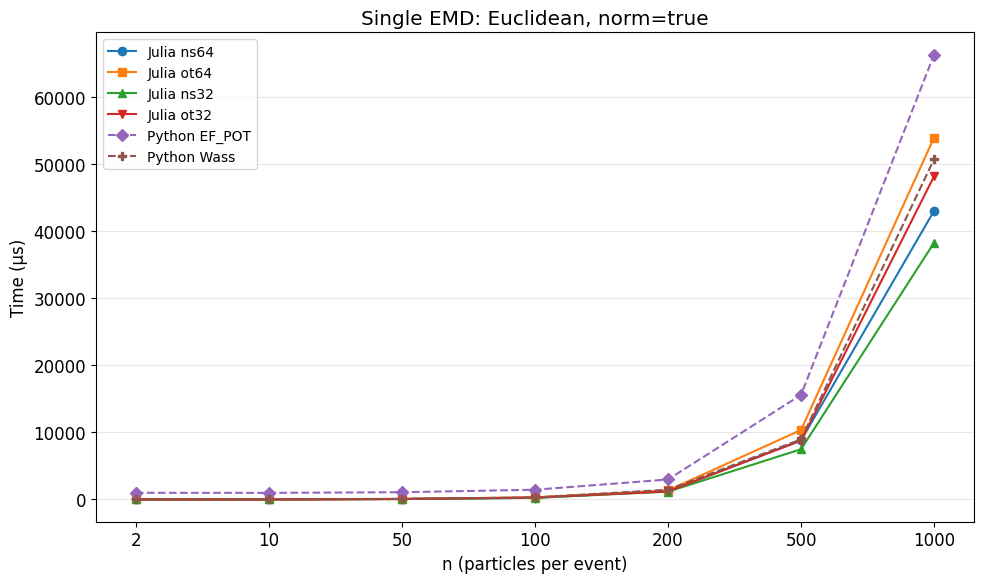

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
sizes = [2, 10, 50, 100, 200, 500, 1000]
x_pos = np.arange(len(sizes))

setup = 'Euclidean_norm'
for backend, color, marker in [('ns64','C0','o'), ('ot64','C1','s'), ('ns32','C2','^'), ('ot32','C3','v')]:
    mask = (jl_single['Setup']==setup) & (jl_single['Backend']==backend) & (jl_single['n0']==jl_single['n1'])
    d = jl_single[mask].sort_values('n0')
    vals = [d[d['n0']==n]['Median (\u00b5s)'].values[0] if len(d[d['n0']==n])>0 else np.nan for n in sizes]
    ax.plot(x_pos, vals, f'-{marker}', color=color, label=f'Julia {backend}', markersize=6)

for backend, color, marker in [('EF_POT','C4','D'), ('Wass','C5','P')]:
    mask = (py_single['Setup']==setup) & (py_single['Backend']==backend) & (py_single['n0']==py_single['n1'])
    d = py_single[mask].sort_values('n0')
    vals = [d[d['n0']==n]['Time (\u00b5s)'].values[0] if len(d[d['n0']==n])>0 else np.nan for n in sizes]
    ax.plot(x_pos, vals, f'--{marker}', color=color, label=f'Python {backend}', markersize=6)

ax.set_xticks(x_pos)
ax.set_xticklabels(sizes)
ax.set_xlabel('n (particles per event)')
ax.set_ylabel('Time (\u00b5s)')
ax.set_title('Single EMD: Euclidean, norm=true')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_single_emd_scaling.png', dpi=150)
plt.show()

## Plot 2: Single EMD \u2014 norm=true vs norm=false (ns64 vs Python)

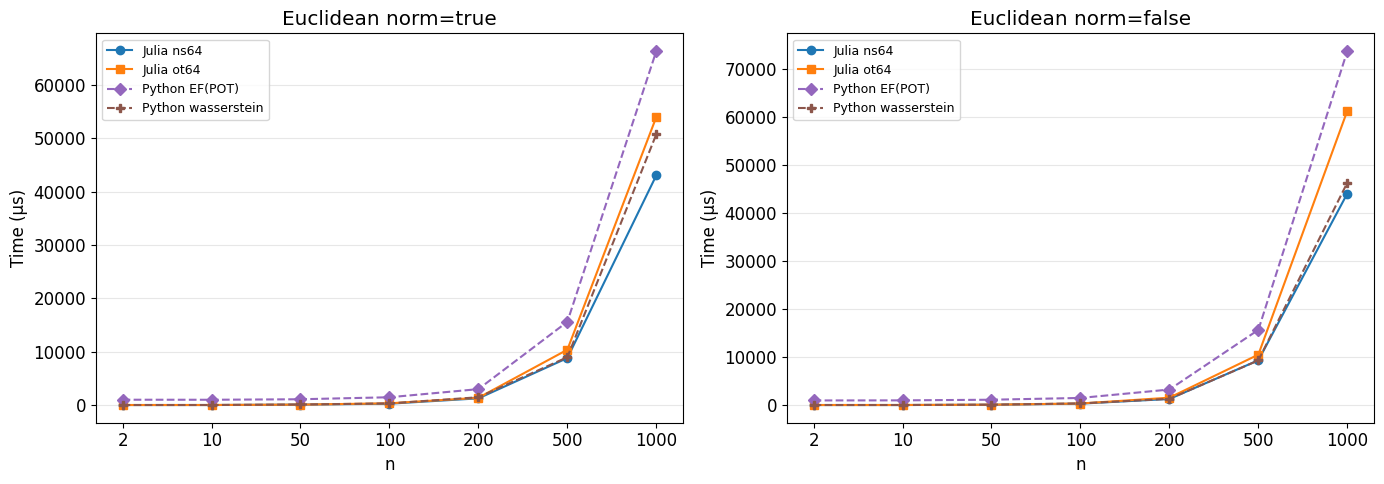

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sizes = [2, 10, 50, 100, 200, 500, 1000]
x_pos = np.arange(len(sizes))

for idx, (setup, title) in enumerate([('Euclidean_norm', 'Euclidean norm=true'), ('Euclidean_unnorm', 'Euclidean norm=false')]):
    ax = axes[idx]
    # Julia ns64
    mask = (jl_single['Setup']==setup) & (jl_single['Backend']=='ns64') & (jl_single['n0']==jl_single['n1'])
    d = jl_single[mask].sort_values('n0')
    vals = [d[d['n0']==n]['Median (\u00b5s)'].values[0] if len(d[d['n0']==n])>0 else np.nan for n in sizes]
    ax.plot(x_pos, vals, '-o', color='C0', label='Julia ns64')

    # Julia ot64
    mask = (jl_single['Setup']==setup) & (jl_single['Backend']=='ot64') & (jl_single['n0']==jl_single['n1'])
    d = jl_single[mask].sort_values('n0')
    vals = [d[d['n0']==n]['Median (\u00b5s)'].values[0] if len(d[d['n0']==n])>0 else np.nan for n in sizes]
    ax.plot(x_pos, vals, '-s', color='C1', label='Julia ot64')

    # Python EF_POT
    mask = (py_single['Setup']==setup) & (py_single['Backend']=='EF_POT') & (py_single['n0']==py_single['n1'])
    d = py_single[mask].sort_values('n0')
    vals = [d[d['n0']==n]['Time (\u00b5s)'].values[0] if len(d[d['n0']==n])>0 else np.nan for n in sizes]
    ax.plot(x_pos, vals, '--D', color='C4', label='Python EF(POT)')

    # Python Wass
    mask = (py_single['Setup']==setup) & (py_single['Backend']=='Wass') & (py_single['n0']==py_single['n1'])
    d = py_single[mask].sort_values('n0')
    vals = [d[d['n0']==n]['Time (\u00b5s)'].values[0] if len(d[d['n0']==n])>0 else np.nan for n in sizes]
    ax.plot(x_pos, vals, '--P', color='C5', label='Python wasserstein')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(sizes)
    ax.set_xlabel('n'); ax.set_ylabel('Time (\u00b5s)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_single_norm_comparison.png', dpi=150)
plt.show()

## Plot 3: Single EMD \u2014 Asymmetric sizes (n0 \u2260 n1)

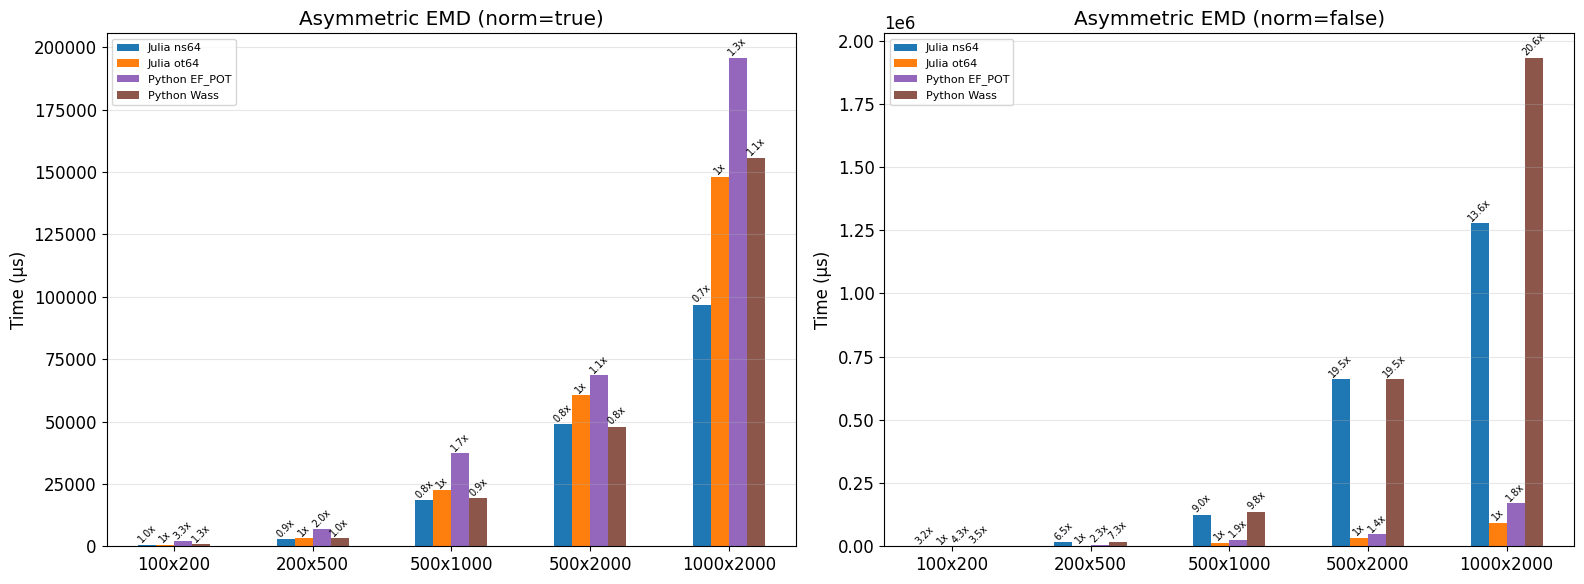

In [38]:
asym_pairs = [(100,200), (200,500), (500,1000), (500,2000), (1000,2000)]
labels = [f'{a}x{b}' for a,b in asym_pairs]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for panel_idx, (setup, title_suffix) in enumerate([('Euclidean_norm','norm=true'), ('Euclidean_unnorm','norm=false')]):
    ax = axes[panel_idx]
    x = np.arange(len(labels))
    width = 0.13
    all_backends = [('ns64','C0','Julia'), ('ot64','C1','Julia'), ('EF_POT','C4','Python'), ('Wass','C5','Python')]

    # Get ns64 baseline values
    ns64_vals = []
    ot64_vals = []
    for n0, n1 in asym_pairs:
        mask = (jl_single['Setup']==setup) & (jl_single['Backend']=='ns64') & (jl_single['n0']==n0) & (jl_single['n1']==n1)
        d = jl_single[mask]
        ns64_vals.append(d['Median (\u00b5s)'].values[0] if len(d)>0 else 1)
        mask = (jl_single['Setup']==setup) & (jl_single['Backend']=='ot64') & (jl_single['n0']==n0) & (jl_single['n1']==n1)
        d = jl_single[mask]
        ot64_vals.append(d['Median (\u00b5s)'].values[0] if len(d)>0 else 1)

    for i, (backend, color, lang) in enumerate(all_backends):
        vals = []
        for n0, n1 in asym_pairs:
            if lang == 'Julia':
                mask = (jl_single['Setup']==setup) & (jl_single['Backend']==backend) & (jl_single['n0']==n0) & (jl_single['n1']==n1)
                d = jl_single[mask]
                vals.append(d['Median (\u00b5s)'].values[0] if len(d)>0 else 0)
            else:
                mask = (py_single['Setup']==setup) & (py_single['Backend']==backend) & (py_single['n0']==n0) & (py_single['n1']==n1)
                d = py_single[mask]
                vals.append(d['Time (\u00b5s)'].values[0] if len(d)>0 else 0)

        bars = ax.bar(x + i*width, vals, width, label=f'{lang} {backend}', color=color)

        # Add ratio labels
        for j, (bar, val) in enumerate(zip(bars, vals)):
            if ot64_vals[j] > 0 and val > 0:
                ratio = val / ot64_vals[j]
                label_text = "1x" if backend == 'ot64' else f"{ratio:.1f}x"
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                       label_text, ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_xticks(x + 1.5*width)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Time (\u00b5s)')
    ax.set_title(f'Asymmetric EMD ({title_suffix})')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_single_asymmetric.png', dpi=150)
plt.show()

## Plot 4: Pairwise EMD \u2014 Julia vs Python (1 thread vs 8 threads)

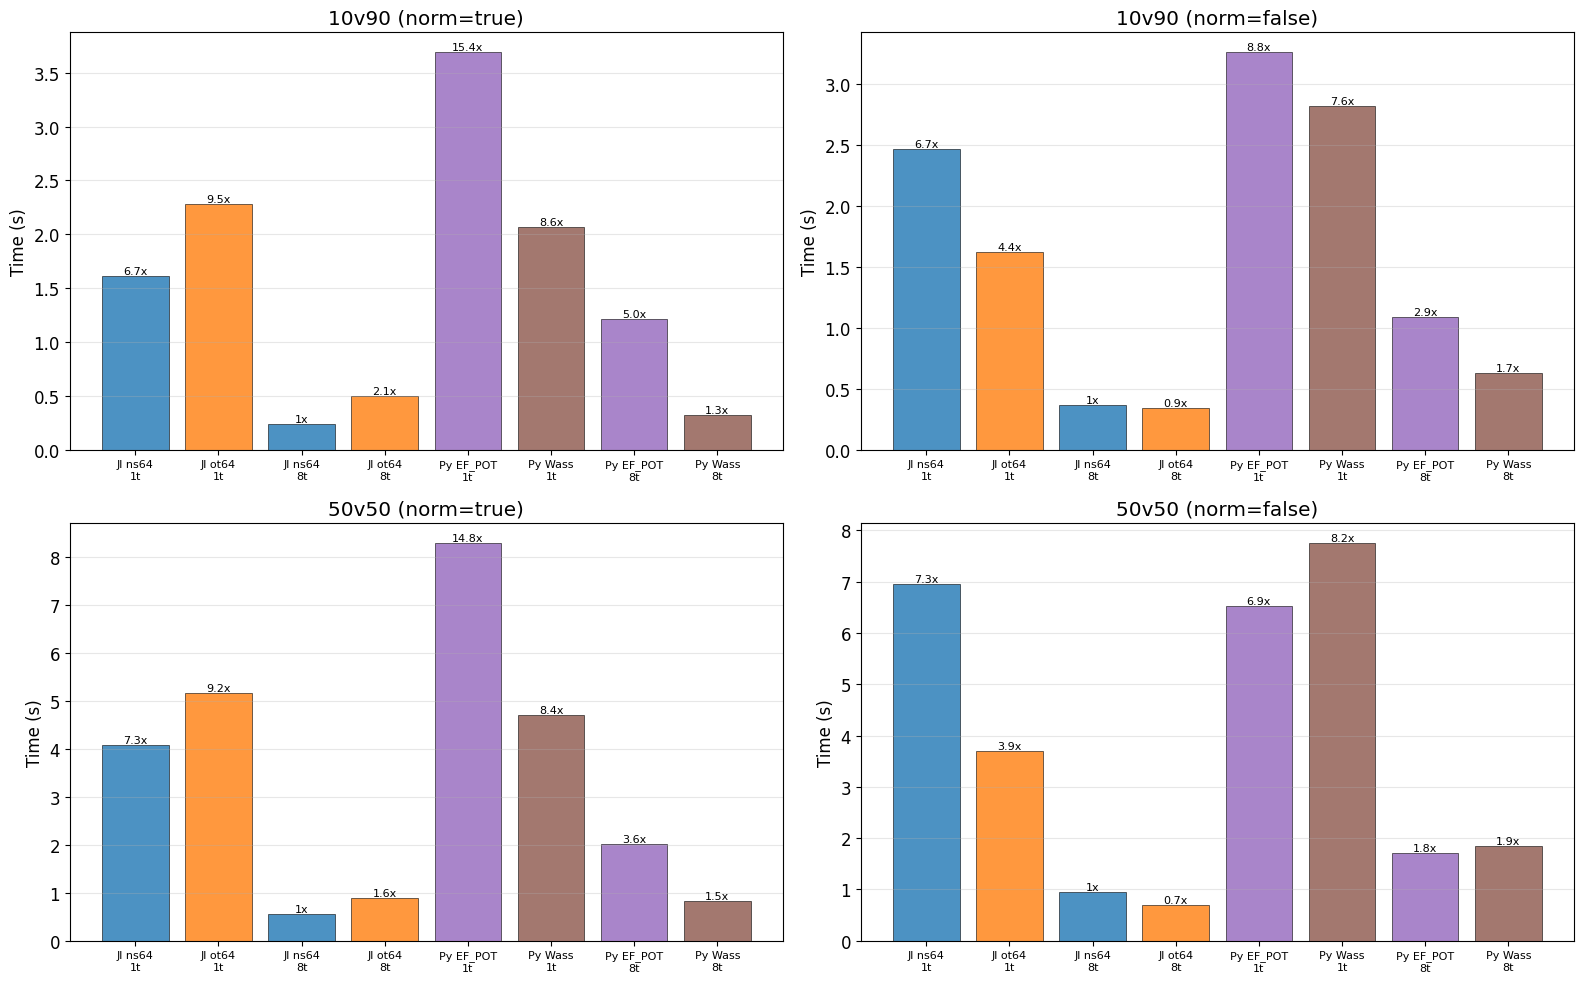

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, split in enumerate(['10v90', '50v50']):
    for col, (setup, title_norm) in enumerate([('Euclidean_norm','norm=true'), ('Euclidean_unnorm','norm=false')]):
        ax = axes[row][col]
        bars_data = []
        labels_list = []
        colors = []

        # Julia 1t ns64, ot64
        for backend in ['ns64', 'ot64']:
            mask = (jl_emds_1t['Split']==split) & (jl_emds_1t['Setup']==setup) & (jl_emds_1t['Backend']==backend)
            d = jl_emds_1t[mask]
            if len(d)>0:
                bars_data.append(d['Time (s)'].values[0])
                labels_list.append(f'Jl {backend}\n1t')
                colors.append('C0' if backend=='ns64' else 'C1')

        # Julia 8t ns64, ot64
        for backend in ['ns64', 'ot64']:
            mask = (jl_emds_8t['Split']==split) & (jl_emds_8t['Setup']==setup) & (jl_emds_8t['Backend']==backend)
            d = jl_emds_8t[mask]
            if len(d)>0:
                bars_data.append(d['Time (s)'].values[0])
                labels_list.append(f'Jl {backend}\n8t')
                colors.append('C0' if backend=='ns64' else 'C1')

        # Python 1t
        for backend in ['EF_POT', 'Wass']:
            mask = (py_emds_1t['Split']==split) & (py_emds_1t['Setup']==setup) & (py_emds_1t['Backend']==backend)
            d = py_emds_1t[mask]
            if len(d)>0:
                bars_data.append(d['Time (s)'].values[0])
                labels_list.append(f'Py {backend}\n1t')
                colors.append('C4' if backend=='EF_POT' else 'C5')

        # Python 8t
        for backend in ['EF_POT', 'Wass']:
            mask = (py_emds_8t['Split']==split) & (py_emds_8t['Setup']==setup) & (py_emds_8t['Backend']==backend)
            d = py_emds_8t[mask]
            if len(d)>0:
                bars_data.append(d['Time (s)'].values[0])
                labels_list.append(f'Py {backend}\n8t')
                colors.append('C4' if backend=='EF_POT' else 'C5')

        # Find ns64 8t baseline for ratios
        ns64_8t_val = None
        for i, lbl in enumerate(labels_list):
            if 'ns64' in lbl and '8t' in lbl:
                ns64_8t_val = bars_data[i]
                break

        x = np.arange(len(bars_data))
        bar_objs = ax.bar(x, bars_data, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

        # Add ratio labels
        if ns64_8t_val and ns64_8t_val > 0:
            for i, (bar, val) in enumerate(zip(bar_objs, bars_data)):
                ratio = val / ns64_8t_val
                label_text = "1x" if ('ns64' in labels_list[i] and '8t' in labels_list[i]) else f"{ratio:.1f}x"
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                       label_text, ha='center', va='bottom', fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels(labels_list, fontsize=8)
        ax.set_ylabel('Time (s)')
        ax.set_title(f'{split} ({title_norm})')
        ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_emds_comparison.png', dpi=150)
plt.show()

## Plot 5: Julia Backend Comparison (Float64 vs Float32)

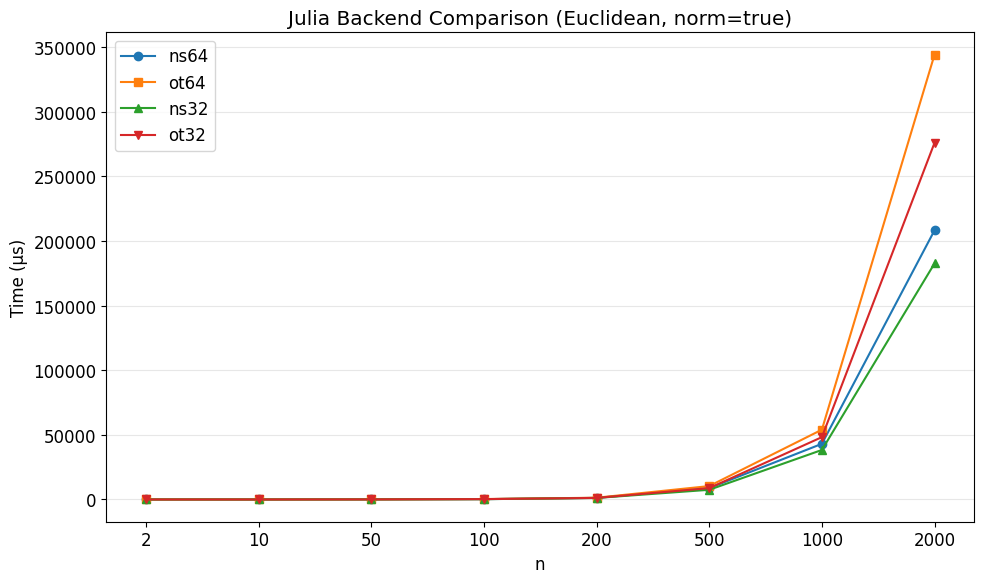

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
sizes = [2, 10, 50, 100, 200, 500, 1000, 2000]
x_pos = np.arange(len(sizes))

setup = 'Euclidean_norm'
for backend, color, marker in [('ns64','C0','o'), ('ot64','C1','s'), ('ns32','C2','^'), ('ot32','C3','v')]:
    mask = (jl_single['Setup']==setup) & (jl_single['Backend']==backend) & (jl_single['n0']==jl_single['n1'])
    d = jl_single[mask].sort_values('n0')
    vals = [d[d['n0']==n]['Median (\u00b5s)'].values[0] if len(d[d['n0']==n])>0 else np.nan for n in sizes]
    ax.plot(x_pos, vals, f'-{marker}', color=color, label=backend, markersize=6)

ax.set_xticks(x_pos)
ax.set_xticklabels(sizes)
ax.set_xlabel('n')
ax.set_ylabel('Time (\u00b5s)')
ax.set_title('Julia Backend Comparison (Euclidean, norm=true)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_backend_comparison.png', dpi=150)
plt.show()

## Plot 6: Speedup \u2014 Julia vs Python

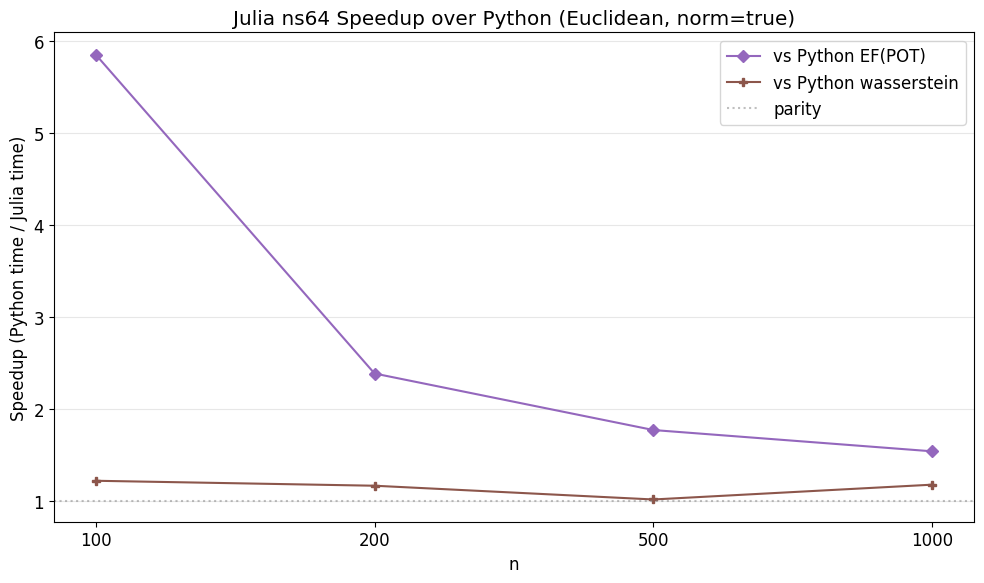

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))
sizes = [100, 200, 500, 1000]
x_pos = np.arange(len(sizes))

setup = 'Euclidean_norm'

# Julia ns64 times
jl_mask = (jl_single['Setup']==setup) & (jl_single['Backend']=='ns64') & (jl_single['n0']==jl_single['n1'])
jl_d = jl_single[jl_mask].sort_values('n0')

# Python EF_POT times
py_ef_mask = (py_single['Setup']==setup) & (py_single['Backend']=='EF_POT') & (py_single['n0']==py_single['n1'])
py_ef_d = py_single[py_ef_mask].sort_values('n0')

# Python Wass times
py_w_mask = (py_single['Setup']==setup) & (py_single['Backend']=='Wass') & (py_single['n0']==py_single['n1'])
py_w_d = py_single[py_w_mask].sort_values('n0')

# Compute speedup for each size
speedup_ef = []
speedup_w = []
for n in sizes:
    jl_val = jl_d[jl_d['n0']==n]['Median (\u00b5s)'].values
    ef_val = py_ef_d[py_ef_d['n0']==n]['Time (\u00b5s)'].values
    w_val = py_w_d[py_w_d['n0']==n]['Time (\u00b5s)'].values
    if len(jl_val)>0 and len(ef_val)>0 and jl_val[0]>0:
        speedup_ef.append(ef_val[0] / jl_val[0])
    else:
        speedup_ef.append(np.nan)
    if len(jl_val)>0 and len(w_val)>0 and jl_val[0]>0:
        speedup_w.append(w_val[0] / jl_val[0])
    else:
        speedup_w.append(np.nan)

ax.plot(x_pos, speedup_ef, '-D', color='C4', label='vs Python EF(POT)', markersize=6)
ax.plot(x_pos, speedup_w, '-P', color='C5', label='vs Python wasserstein', markersize=6)
ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5, label='parity')

ax.set_xticks(x_pos)
ax.set_xticklabels(sizes)
ax.set_xlabel('n')
ax.set_ylabel('Speedup (Python time / Julia time)')
ax.set_title('Julia ns64 Speedup over Python (Euclidean, norm=true)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_speedup.png', dpi=150)
plt.show()